# Introduction to Neural Networks

**This is not part of the curriculum for MAT230 in the spring of 2026. It is intended for perspectives.**

A **neural network** is a computational model inspired by the structure and function of biological neural systems in the brain. It consists of interconnected units called **neurons** (or **nodes**) organized into layers that work together to learn patterns from data.

## Basic Architecture

![](https://en.wikipedia.org/wiki/File:Neural_network_example.svg)

Neural networks typically have three types of layers:

1. **Input layer**: receives raw data (features)
2. **Hidden layers**: perform nonlinear transformations through weighted connections and activation functions
3. **Output layer**: produces predictions or decisions



![Artificial neural network](https://upload.wikimedia.org/wikipedia/commons/2/2f/Example_of_a_deep_neural_network.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original)

Taken from here https://upload.wikimedia.org/wikipedia/commons/2/2f/Example_of_a_deep_neural_network.png

![](https://raw.githubusercontent.com/dvgodoy/dl-visuals/main/Classification/logistic_model.png)


## How Neural Networks Learn

Each connection between neurons has an associated **weight** and **bias**. During training, the network adjusts these parameters to minimize prediction error using an optimization algorithm (e.g., gradient descent). The key steps are:

- **Forward pass**: data flows through the network to produce an output
- **Loss computation**: the difference between predicted and true values is measured
- **Backward pass**: gradients are computed via backpropagation
- **Weight update**: parameters are adjusted to reduce loss

## Activation Functions

To capture nonlinear relationships, neural networks use **activation functions** at each neuron:

- **ReLU** (Rectified Linear Unit): $\phi(x) = \max(0, x)$
- **Tanh**: $\phi(x) = \tanh(x)$, outputs in $(-1, 1)$
- **Sigmoid**: $\phi(x) = \frac{1}{1+e^{-x}}$, outputs in $(0, 1)$

Without activation functions, stacking layers would only perform linear transformations, severely limiting expressiveness.

## Why Neural Networks?

Neural networks excel at:

- **Learning complex patterns**: multiple layers can represent intricate decision boundaries
- **Generalization**: trained on data, they often work well on unseen examples
- **Flexibility**: applicable to diverse tasks (classification, regression, sequence modeling, etc.)

Reservoir computing and echo state networks, which we explore in this notebook, offer a particular approach to neural computation optimized for **temporal and dynamical data**.

## Introduction to Echo State Networks and Reservoir Computing

**Reservoir Computing (RC)** is a framework for processing time-dependent data using a fixed, high-dimensional dynamical system called a **reservoir**.  
Instead of training all network weights, RC keeps the internal reservoir connections unchanged and only trains a simple output layer. This makes learning fast and computationally efficient, while still capturing complex temporal patterns.

An **Echo State Network (ESN)** is one of the most widely used reservoir computing models. It consists of three parts:

1. **Input layer**: projects the input signal into the reservoir.
2. **Reservoir**: a recurrent network with fixed random connections that creates rich nonlinear dynamics.
3. **Readout layer**: a trainable linear (or mildly nonlinear) mapping from reservoir states to the target output.

The key idea behind ESNs is the **echo state property**: the reservoir state should be driven mainly by recent inputs, so past information is represented as fading “echoes” in the network dynamics.  
Because only the readout is trained, ESNs are particularly useful for tasks such as time-series prediction, system identification, and signal classification.



![](https://reservoirpy.readthedocs.io/en/latest/_images/esn.svg.png)
![](https://reservoirpy.readthedocs.io/en/latest/_images/esn_nodes.svg.png)

Taken from ReservoirPy: https://reservoirpy.readthedocs.io

## ESN State-Update Equations

For input $u_t \in \mathbb{R}^{n_u}$, reservoir state $x_t \in \mathbb{R}^{n_r}$, and output $y_t$, a standard Echo State Network (ESN) update is:

$$
x_{t+1} = (1-\alpha)x_t + \alpha\,\phi\!\left(W_{\text{in}}u_{t+1} + W x_t + b\right)
$$

$$
y_{t+1} = W_{\text{out}} x_{t+1}
$$

where:

- $W_{\text{in}}$: input-to-reservoir weights  
- $W$: recurrent reservoir matrix (fixed/random)  
- $W_{\text{out}}$: readout weights (trained)  
- $\phi(\cdot)$: elementwise nonlinearity (e.g., $\tanh$)  
- $\alpha \in (0,1]$: leak rate

## Comparison with Traditional Neural Networks

### Key Differences

| Aspect | Traditional RNN/LSTM | Reservoir Computing (ESN) |
|--------|---------------------|--------------------------|
| **Training** | All weights trained via backpropagation | Only output layer trained |
| **Computational Cost** | High (BPTT, multiple epochs) | Low (single linear regression) |
| **Memory Mechanism** | Learned gating (LSTM cells) | Fixed random dynamics |
| **Stability** | Can suffer from vanishing/exploding gradients | Controlled via spectral radius |
| **Best For** | Very long sequences, complex patterns | Temporal modeling, fast prototyping |

### Advantages of Reservoir Computing

- **Speed**: Linear readout training vs. iterative RNN optimization
- **Simplicity**: Fewer hyperparameters to tune (mainly $\rho$, leak rate, input scaling)
- **Theoretical grounding**: Direct connection to dynamical systems theory
- **Scalability**: Reservoir size can be very large without training overhead

### When to Use ESNs vs. Traditional RNNs

Choose **ESNs** when you need:
- Quick prototyping and fast training
- Interpretable dynamics-based models
- Limited computational resources
- Tasks with moderate sequence length

Choose **RNNs/LSTMs** when you need:
- State-of-the-art performance on complex benchmarks
- Adaptive, learnable temporal features
- Very long-term dependencies in data

Both approaches—traditional neural networks and reservoir computing—offer complementary strengths in modeling temporal and dynamical systems. 

## Dynamical-Systems View

An ESN is a **forced nonlinear discrete-time dynamical system**:

$$
x_{t+1} = F(x_t, u_{t+1})
$$

- Without input ($u_t=0$), the reservoir follows autonomous dynamics set by $W$, $\phi$, and $\alpha$.
- With input, trajectories are driven by the signal, so $x_t$ is a high-dimensional embedding of recent history.
- The **echo state property** means dependence on initial state fades over time, so dynamics are mainly determined by input history (often encouraged by spectral-radius control, e.g., $\rho(W)\lesssim 1$).

## Spectral Radius and Linear Stability (ODE Analogy)

A useful way to interpret ESN tuning is through the same lens as **linear stability analysis** for ODEs.

For an ODE near an equilibrium $x^*$:
$$
\dot{\delta x} = J\,\delta x, \quad J=\left.\frac{\partial f}{\partial x}\right|_{x^*}
$$
stability is set by eigenvalues of $J$: if all $\Re(\lambda_i)<0$, perturbations decay.

For a discrete-time map (like an ESN state update), local perturbations follow:
$$
\delta x_{t+1} \approx A\,\delta x_t
$$
and stability requires eigenvalues of $A$ to lie inside the unit disk:
$$
|\lambda_i(A)|<1 \;\;\Longleftrightarrow\;\; \rho(A)<1
$$
where $\rho(\cdot)$ is the **spectral radius**.

In ESNs (ignoring input and around a local operating point), $A$ is roughly the reservoir Jacobian, often approximated by scaled $W$ (plus leak/nonlinearity factors). So:

- $\rho$ too small $\rightarrow$ fast contraction, short memory  
- $\rho$ near $1$ $\rightarrow$ slow decay, richer memory (“edge of stability”)  
- $\rho>1$ $\rightarrow$ risk of unstable/chaotic internal dynamics

So the ESN spectral-radius heuristic is the discrete-time analogue of placing ODE Jacobian eigenvalues in the stable region.

## Introduction to ReservoirPy

**ReservoirPy** is an open-source Python library for building and training **reservoir computing** models, especially **Echo State Networks (ESNs)**.  
It is designed to make recurrent dynamical models easy to prototype while keeping the training process lightweight and efficient.

### Why use ReservoirPy?

- **Fast training**: only the readout layer is usually trained (often with linear regression).
- **Modular design**: combine components such as `Input`, `Reservoir`, and `Ridge` readouts in flexible pipelines.
- **Scikit-learn style workflow**: intuitive `fit` / `run` patterns for experiments.
- **Good for temporal data**: useful for time-series prediction, sequence modeling, and dynamical system tasks.
- **Research-friendly**: supports reproducible experiments and rapid testing of reservoir configurations.

### Typical ESN workflow in ReservoirPy

1. Define the reservoir size and hyperparameters (spectral radius, leak rate, input scaling, etc.).
2. Build the model by chaining nodes (input → reservoir → readout).
3. Train only the readout on collected reservoir states.
4. Evaluate predictions on unseen sequential data.

ReservoirPy is a practical choice when you want recurrent temporal modeling with lower training cost than fully trained RNNs.

## Mackey–Glass Example: Why this benchmark?

The Mackey–Glass signal is a classic nonlinear, delayed dynamical system often used to evaluate short-term memory and prediction in recurrent models.  
In continuous time, it is defined by

$$
\frac{dx(t)}{dt} = \beta \frac{x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t),
$$

where $\tau$ is a delay and $(\beta,\gamma,n)$ control nonlinearity and dissipation.  
For common settings (e.g., $\beta=0.2$, $\gamma=0.1$, $n=10$, $\tau=17$), the dynamics are complex and can be chaotic.

After sampling, we obtain a scalar sequence $\{s_t\}$.  
The one-step forecasting task is:

$$
u_t = s_t, \qquad y_t^{\text{target}} = s_{t+1}.
$$

In the ESN, the reservoir state evolves as

$$
x_{t+1} = (1-\alpha)x_t + \alpha\,\tanh\!\left(W_{\text{in}}u_{t+1} + Wx_t + b\right),
$$

and the readout predicts

$$
\hat{y}_{t+1} = W_{\text{out}}x_{t+1}.
$$

Only $W_{\text{out}}$ is trained (ridge regression), while $W$ remains fixed.  
This makes training fast, while still capturing delayed temporal structure.  
Performance is measured with mean squared error:

$$
\mathrm{MSE} = \frac{1}{N}\sum_{t=1}^{N}\left(y_t^{\text{target}}-\hat{y}_t\right)^2.
$$

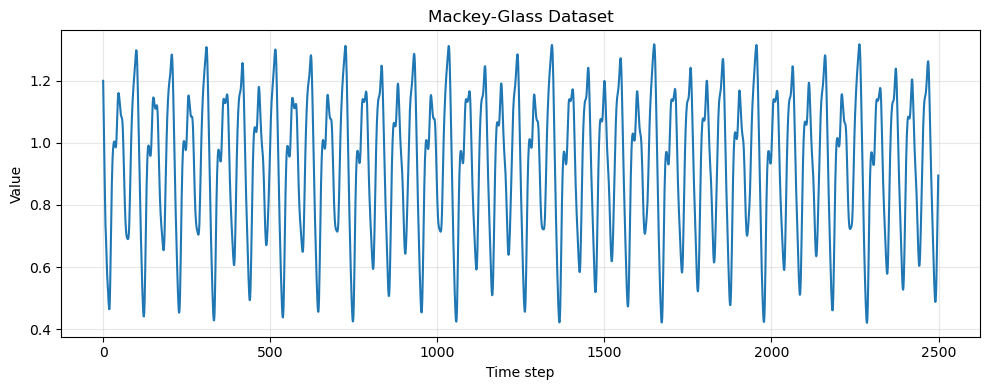

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from reservoirpy.datasets import mackey_glass
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import mse

plt.figure(figsize=(10, 4))
plt.plot(np.asarray(series).ravel(), linewidth=1.5)
plt.title("Mackey-Glass Dataset")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Setting up ReservoirPy for Mackey-Glass


Test MSE: 0.000005


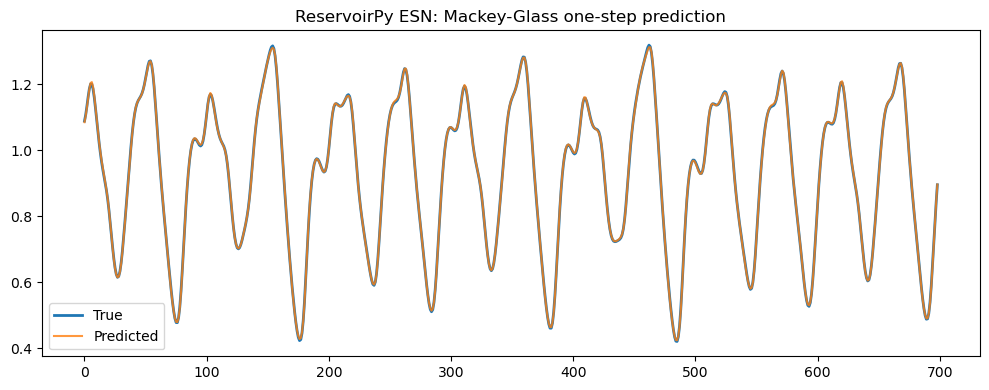

Error (first 10):
[ 0.00338611  0.00342207  0.00338139  0.00271608  0.00045032 -0.00312903
 -0.00602032 -0.00637276 -0.00436899 -0.00181   ]
MSE: 4.919182e-06


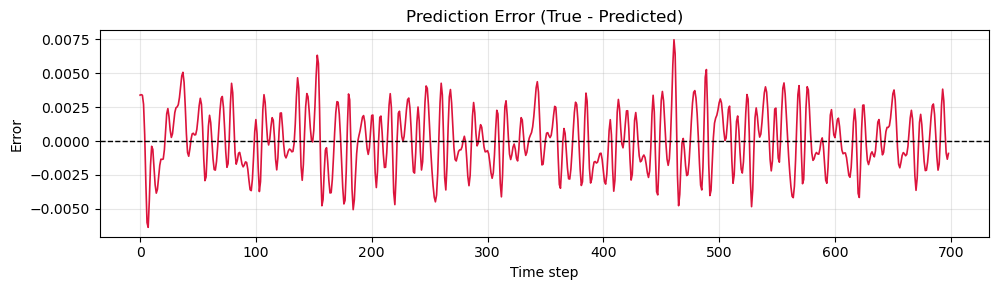

In [20]:

# Quick ESN example (inspired by ReservoirPy docs)
series = mackey_glass(2500).reshape(-1, 1)

train_len = 1800
train = series[:train_len]
test = series[train_len:]

# Build ESN: Reservoir -> Ridge readout
esn = Reservoir(units=200, sr=1.1, lr=0.3, input_scaling=0.4, seed=42) >> Ridge(ridge=1e-5)

# One-step-ahead forecasting
esn.fit(train[:-1], train[1:], warmup=100)
pred = esn.run(test[:-1])

err = mse(test[1:], pred)
print(f"Test MSE: {err:.6f}")

plt.figure(figsize=(10, 4))
plt.plot(test[1:], label="True", linewidth=2)
plt.plot(pred, label="Predicted", alpha=0.8)
plt.title("ReservoirPy ESN: Mackey-Glass one-step prediction")
plt.legend()
plt.tight_layout()
plt.show()
# Point-wise prediction error
error = test[1:] - pred

print("Error (first 10):")
print(error[:10].ravel())

print(f"MSE: {err:.6e}")

plt.figure(figsize=(10, 3))
plt.plot(error, color="crimson", linewidth=1.2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Prediction Error (True - Predicted)")
plt.xlabel("Time step")
plt.ylabel("Error")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Try this:** can you do the discrete Logistic equation?

## Lorenz System: Multi-Output Prediction with ESN

The **Lorenz system** is a classic chaotic dynamical system defined by three coupled ODEs:

$$
\dot{x} = \sigma(y - x), \quad \dot{y} = x(\rho - z) - y, \quad \dot{z} = xy - \beta z
$$

with standard parameters $\sigma=10$, $\rho=28$, $\beta=8/3$, producing the famous **butterfly attractor**.

### Why Lorenz?

- It is a canonical benchmark for chaotic time-series modeling.
- It tests the reservoir's ability to reconstruct a **high-dimensional attractor** from limited observations.
- It naturally extends ESNs to a **multi-output** setting.

### Our Task

Rather than feeding all three variables into the ESN, we will use only the **$x(t)$ component** as input:

$$
u_t = x_t
$$

The readout is then trained to simultaneously predict the other two components:

$$
\hat{v}_t = W_{\text{out}}  x_t^{\text{ESN}}  \approx \begin{bmatrix}  y_t \\ z_t \end{bmatrix}
$$

This tests whether the reservoir's **nonlinear memory** is rich enough to reconstruct the full attractor from a single scalar observation — a form of **attractor reconstruction** inspired by Takens' embedding theorem.

MSE(y): 0.261508
MSE(z): 97.940374


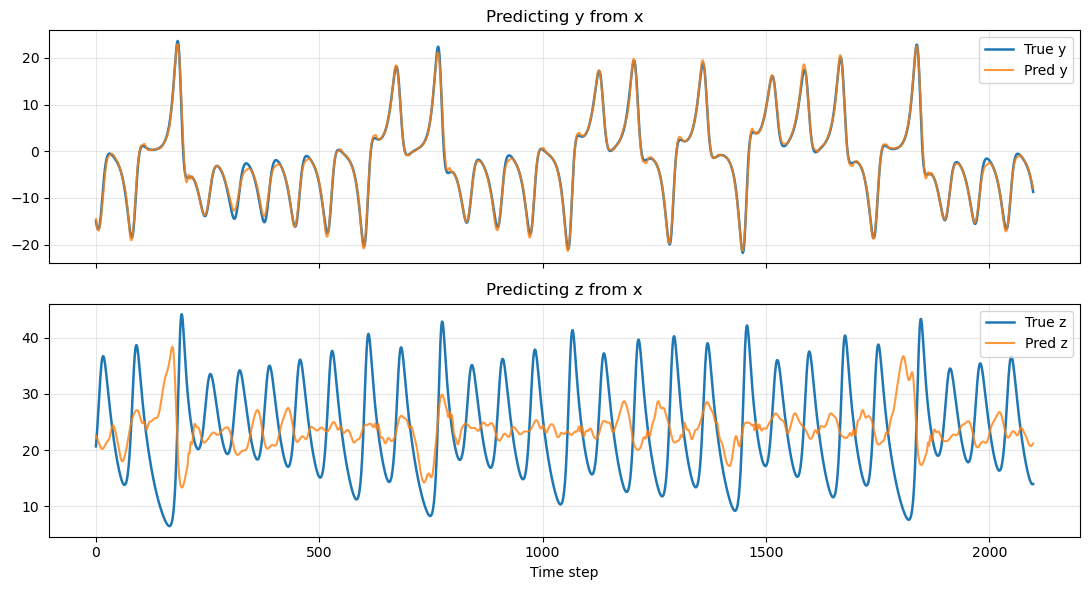

In [21]:
# Predict y(t+1), z(t+1) from x(t) on the Lorenz system

def lorenz_rhs(state, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = state
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])
    # Make targets compatible with the existing fit/run slicing so the mapping is x(t) -> [y(t), z(t)]
def align_targets_same_timestep(targets: np.ndarray) -> np.ndarray:
    return np.vstack([targets[:1], targets[:-1]])
def simulate_lorenz(n_steps=7000, dt=0.01, x0=np.array([1.0, 1.0, 1.0])):
    data = np.zeros((n_steps, 3))
    data[0] = x0
    for t in range(n_steps - 1):
        s = data[t]
        k1 = lorenz_rhs(s)
        k2 = lorenz_rhs(s + 0.5 * dt * k1)
        k3 = lorenz_rhs(s + 0.5 * dt * k2)
        k4 = lorenz_rhs(s + dt * k3)
        data[t + 1] = s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return data

# 1) Generate data (drop transient)
lorenz = simulate_lorenz(n_steps=8000, dt=0.01)[1000:]
lorenz_norm = lorenz #(lorenz - np.mean(lorenz, axis=0)) / np.std(lorenz, axis=0)
# 2) Input is x only; targets are y and z
u = lorenz_norm[:, [0]]       # shape (T, 1)
yz = lorenz_norm[:, 1:]       # shape (T, 2)

split = int(0.7 * len(lorenz))
u_train, u_test = u[:split], u[split:]
yz_train, yz_test = yz[:split], yz[split:]

# 3) ESN: 1 input -> reservoir -> 2-output ridge readout
esn_yz = Reservoir(units=500, sr=0.9, lr=0.25, input_scaling=0.4, seed=42) >> Ridge(ridge=1e-4)

# one-step-ahead training: x_t -> [y_{t+1}, z_{t+1}]
esn_yz.fit(u_train[:-1], yz_train[1:], warmup=200)
pred_yz = esn_yz.run(u_test[:-1])
true_yz = yz_test[1:]

# 4) Metrics
mse_y = np.mean((true_yz[:, 0] - pred_yz[:, 0])**2)
mse_z = np.mean((true_yz[:, 1] - pred_yz[:, 1])**2)
print(f"MSE(y): {mse_y:.6f}")
print(f"MSE(z): {mse_z:.6f}")

# 5) Plot
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax[0].plot(true_yz[:, 0], label="True y", linewidth=1.8)
ax[0].plot(pred_yz[:, 0], label="Pred y", alpha=0.8)
ax[0].set_title("Predicting y from x")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(true_yz[:, 1], label="True z", linewidth=1.8)
ax[1].plot(pred_yz[:, 1], label="Pred z", alpha=0.8)
ax[1].set_title("Predicting z from x")
ax[1].legend()
ax[1].grid(alpha=0.3)
ax[1].set_xlabel("Time step")

plt.tight_layout()
plt.show()

**Try this:**

- This doesn't look impressive for $z$. Can you fix it? 

- What happens if we give $y$ or $z$ as input?

